# 2. Model Selection & Evaluation

This notebook presents the champion model's performance on the held-out test set,
threshold analysis, temporal stability, confidence intervals, and multi-model benchmarks.

**Prerequisites**: Run `make train` and `make benchmark` to generate required artifacts.

In [1]:
%matplotlib inline

from src.eval.notebook_utils import (
    benchmark_rankings_table,
    benchmark_significance_table,
    load_main_context,
    main_ci_table,
    main_summary_table,
    plot_benchmark_model_comparison,
    plot_main_calibration_hist,
    plot_main_confusion,
    plot_main_roc_pr,
    plot_main_temporal_stability,
    plot_main_threshold_tradeoff,
    setup_plotting,
)

cfg = setup_plotting()
FIG_DIR = cfg["fig_dir"]

ctx = load_main_context()
print("Context loaded successfully.")

Context loaded successfully.


D:\PythonProject1\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 2.1 Pipeline Summary

The training pipeline uses a **champion/challenger rolling-origin** model selection policy.
The champion model family is selected based on mean PR-AUC across rolling temporal folds.

In [2]:
summary = main_summary_table(ctx)
display(summary.T.rename(columns={0: "Value"}).style.set_caption("Model Pipeline Summary"))

,Value
selected_model_family,lightgbm
policy,champion_challenger_rolling_pr_auc_v1
test_roc_auc,0.863758
test_pr_auc,0.761648
max_f1_threshold,0.350000
high_precision_threshold,0.980000


In [3]:
import json
import pandas as pd

summary_path = ctx["root"] / "reports" / "thesis" / "model_family_summary.json"
family_summary = json.loads(summary_path.read_text(encoding="utf-8"))
champion_family = family_summary.get("champion_family", "unknown")

# Prefer fold-level details persisted in model_family_summary.json;
# fall back to model_selection_summary.json for older artifacts.
fold_rows = family_summary.get("rolling_origin_folds", [])
if not fold_rows:
    rolling_path = ctx["root"] / "reports" / "model_selection_summary.json"
    if rolling_path.exists():
        rolling_summary = json.loads(rolling_path.read_text(encoding="utf-8"))
        fold_rows = [
            row
            for row in rolling_summary.get("folds", [])
            if row.get("model_family") == champion_family
        ]

if not fold_rows:
    print("No rolling-origin fold-level details found in reports/thesis/model_family_summary.json.")
else:
    fold_table = (
        pd.DataFrame(fold_rows)
        .sort_values("fold")
        .rename(
            columns={
                "fold": "Fold",
                "cutoff_frac": "Train Cutoff",
                "n_train": "Train Rows",
                "n_val": "Validation Rows",
                "pr_auc": "PR-AUC",
                "roc_auc": "ROC-AUC",
            }
        )
    )
    if "Train Cutoff" in fold_table.columns:
        fold_table["Train Cutoff"] = (fold_table["Train Cutoff"] * 100).map(lambda x: f"{x:.0f}%")

    display_cols = ["Fold", "Train Cutoff", "Train Rows", "Validation Rows", "PR-AUC", "ROC-AUC"]
    display_cols = [col for col in display_cols if col in fold_table.columns]

    display(
        fold_table[display_cols]
        .style
        .format({
            "Train Rows": "{:,.0f}",
            "Validation Rows": "{:,.0f}",
            "PR-AUC": "{:.4f}",
            "ROC-AUC": "{:.4f}",
        })
        .hide(axis="index")
        .set_caption(f"Rolling-Origin Fold Breakdown ({champion_family} champion)")
    )


Fold,Train Cutoff,Train Rows,Validation Rows,PR-AUC,ROC-AUC
1,60%,"64,371","10,728",0.9013,0.9271
2,70%,"75,100","10,728",0.8245,0.8877
3,80%,"85,828","10,728",0.8823,0.9208


## 2.2 ROC and Precision-Recall Curves

Discriminative performance of the champion model on the chronological test set.
ROC-AUC measures overall ranking quality; PR-AUC is more informative under class imbalance.

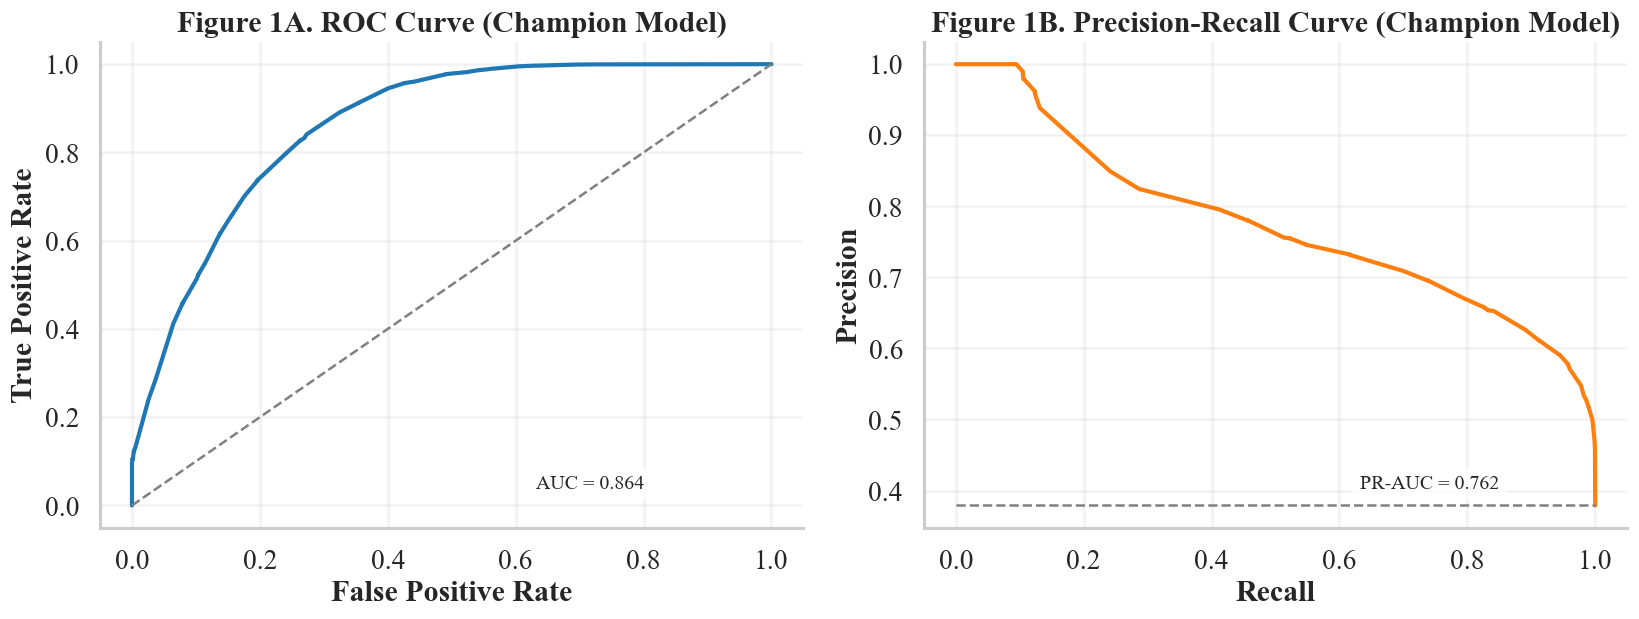

In [4]:
plot_main_roc_pr(ctx, FIG_DIR, fig_no=1)

**Why PR-AUC matters more than ROC-AUC here:** With a 37% cancellation rate, ROC-AUC can be misleadingly optimistic — a naive model still scores ~0.77 because it handles the majority class well. PR-AUC focuses exclusively on how well the model *identifies cancellations* (the positive class). Our champion achieves PR-AUC = 0.7616: it correctly ranks 76% of true cancellations above non-cancellations. This is the metric we used to select our champion model.

## 2.3 Probability Calibration

After isotonic calibration, the predicted probabilities should closely track observed cancellation rates.
The reliability diagram (left) shows calibration quality; the histogram (right) shows probability separation between classes.

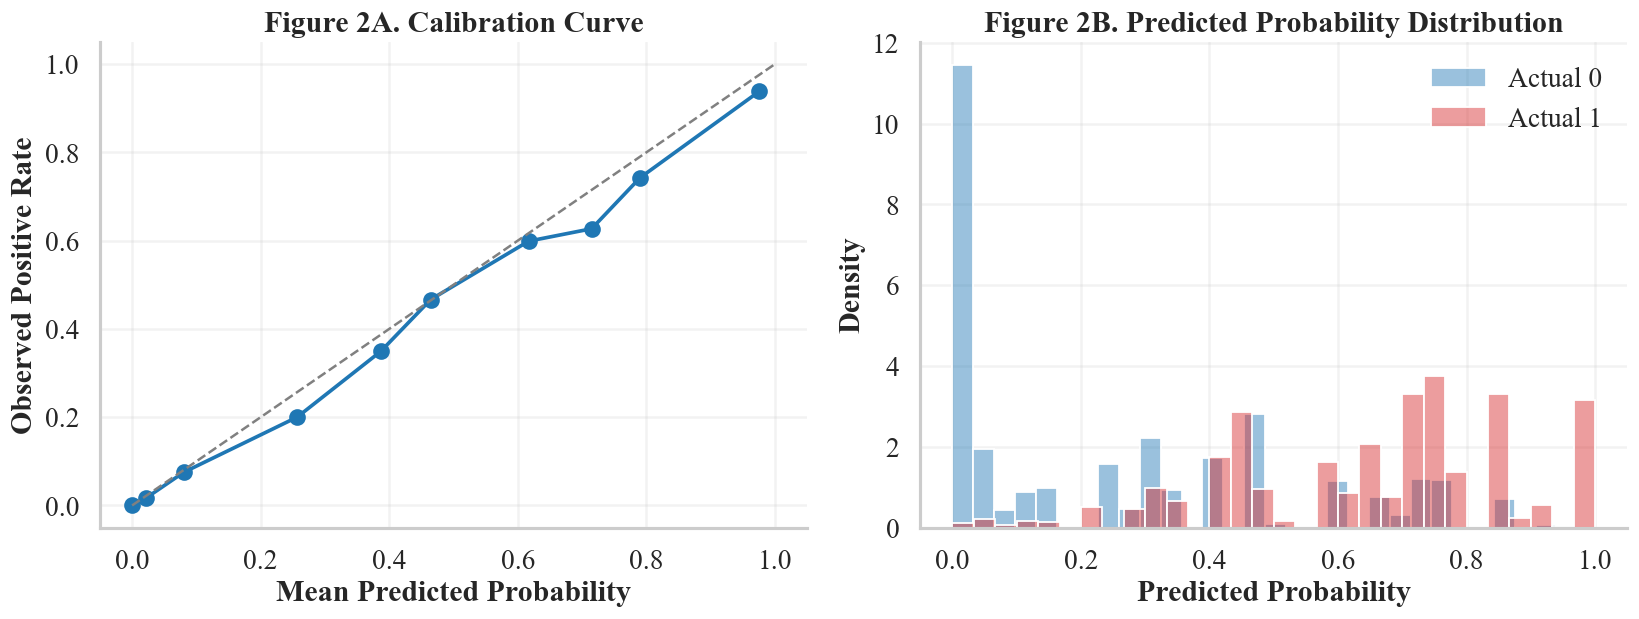

In [5]:
plot_main_calibration_hist(ctx, FIG_DIR, fig_no=2)

**What does "well-calibrated" mean?** A well-calibrated model means predicted probabilities are trustworthy: if the model says “40% chance of cancellation”, roughly 40% of such bookings actually cancel. Our model achieves ECE = 0.0293 (2.9% average error across all probability bins) — excellent calibration. This is essential for the cost-sensitive threshold policy, which uses the probability directly to compute expected revenue at risk.

## 2.4 Confusion Matrix (Max-F1 Policy)

Classification performance at the max-F1 decision threshold. Normalized by true class to show
per-class accuracy (sensitivity and specificity).

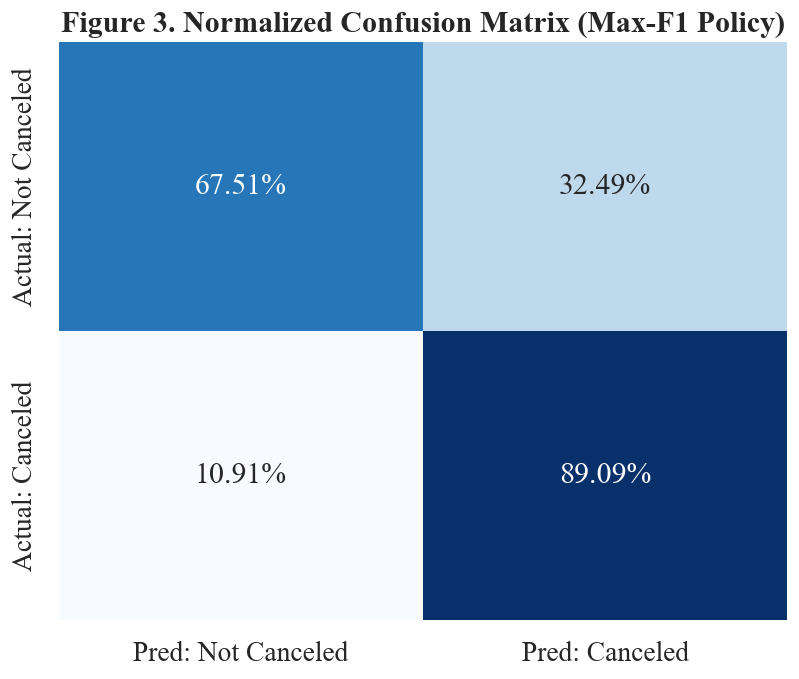

In [6]:
plot_main_confusion(ctx, FIG_DIR, fig_no=3)

## 2.5 Threshold Trade-off Analysis

Precision, recall, F1, and predicted positive rate as a function of the decision threshold.
Vertical lines mark the **max-F1** and **high-precision** policy thresholds.
Dotted horizontal lines show the minimum recall and minimum positive rate constraints.

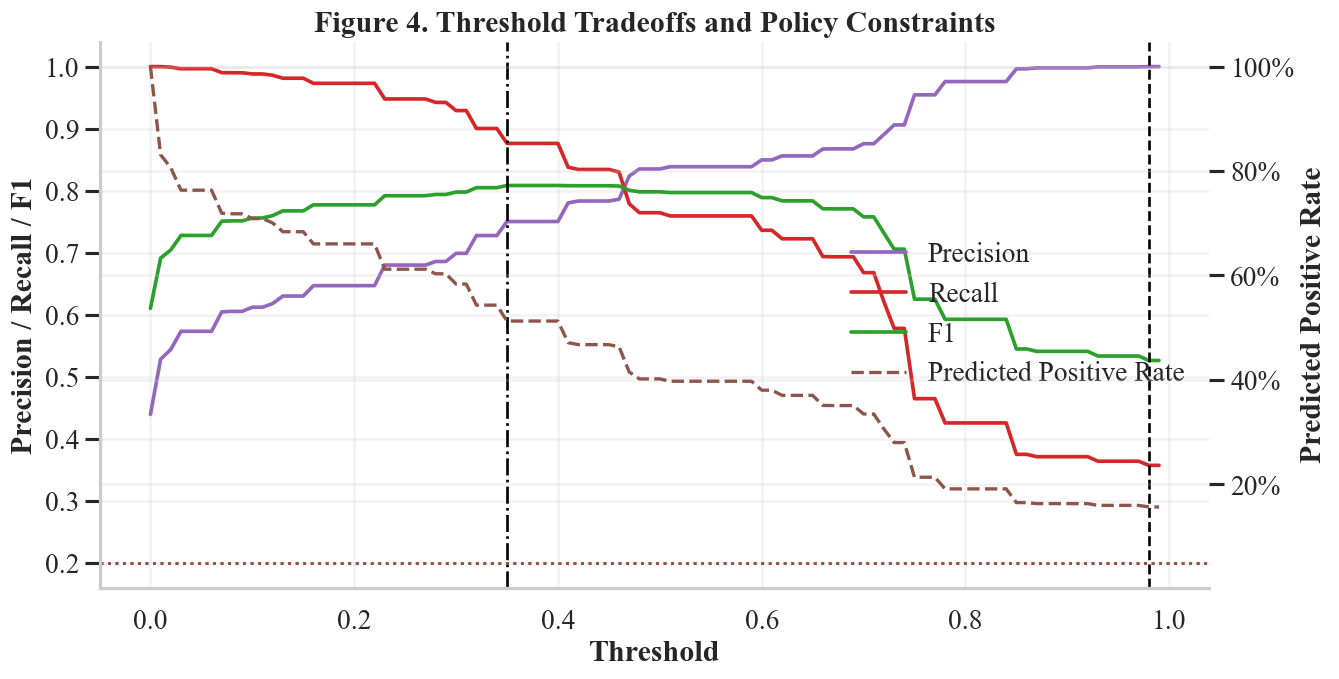

In [7]:
plot_main_threshold_tradeoff(ctx, FIG_DIR, fig_no=4)

## 2.6 Temporal Stability

ROC-AUC and PR-AUC evaluated on chronological buckets within the test set.
Stable performance across time buckets indicates the model generalizes beyond the training period.

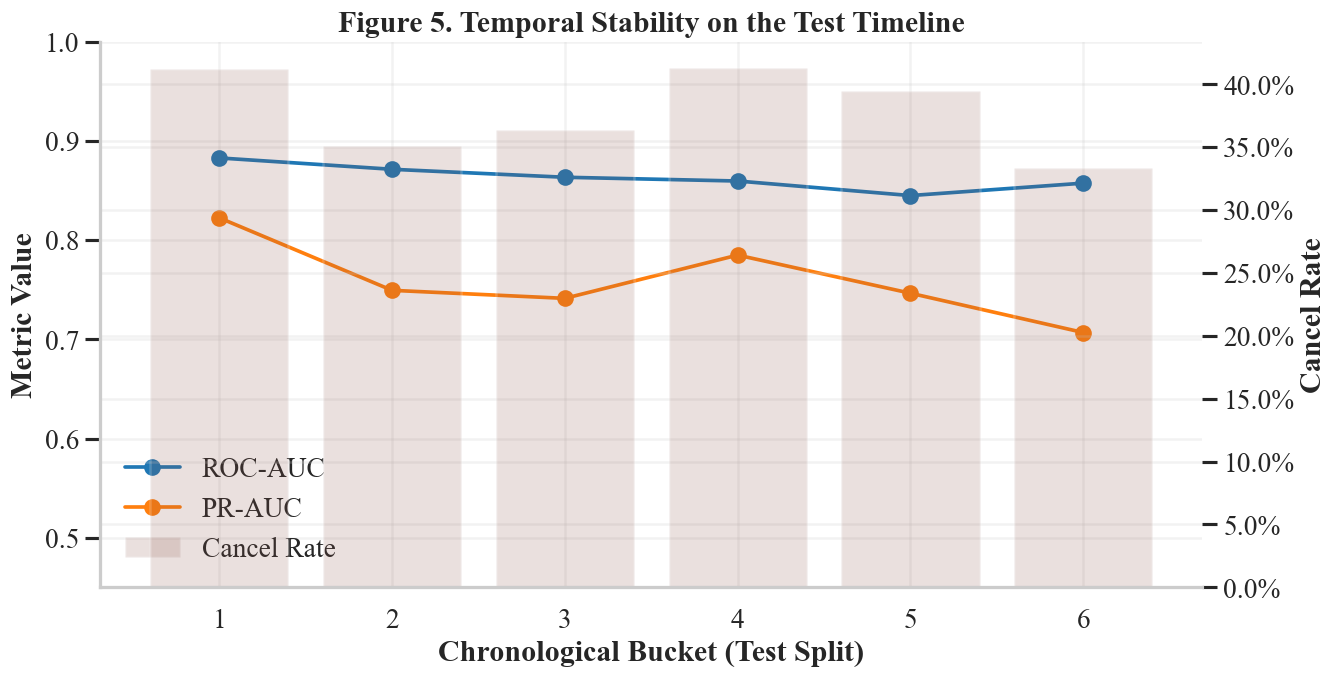

In [8]:
plot_main_temporal_stability(ctx, FIG_DIR, fig_no=5)

## 2.7 Bootstrap Confidence Intervals

95% confidence intervals for key metrics, computed via 2000-iteration bootstrap resampling on the test set.

In [9]:
ci_table = main_ci_table(ctx)
display(
    ci_table.style
    .format({
        "point_estimate": "{:.4f}",
        "ci_lower": "{:.4f}",
        "ci_upper": "{:.4f}",
        "n_bootstraps": "{:.0f}",
    })
    .set_caption("Bootstrap 95% Confidence Intervals (Test Set)")
)

,metric,point_estimate,ci_lower,ci_upper,n_bootstraps
0,f1,0.7349,0.7256,0.7442,2000
1,pr_auc,0.7616,0.7494,0.7740,2000
2,roc_auc,0.8638,0.8574,0.8703,2000


## 2.8 Multi-Model Benchmark Comparison

Comparison across all candidate model families (LightGBM, XGBoost, sklearn GradientBoosting, Logistic Regression, Dummy).
This section requires `make benchmark` to have been run.

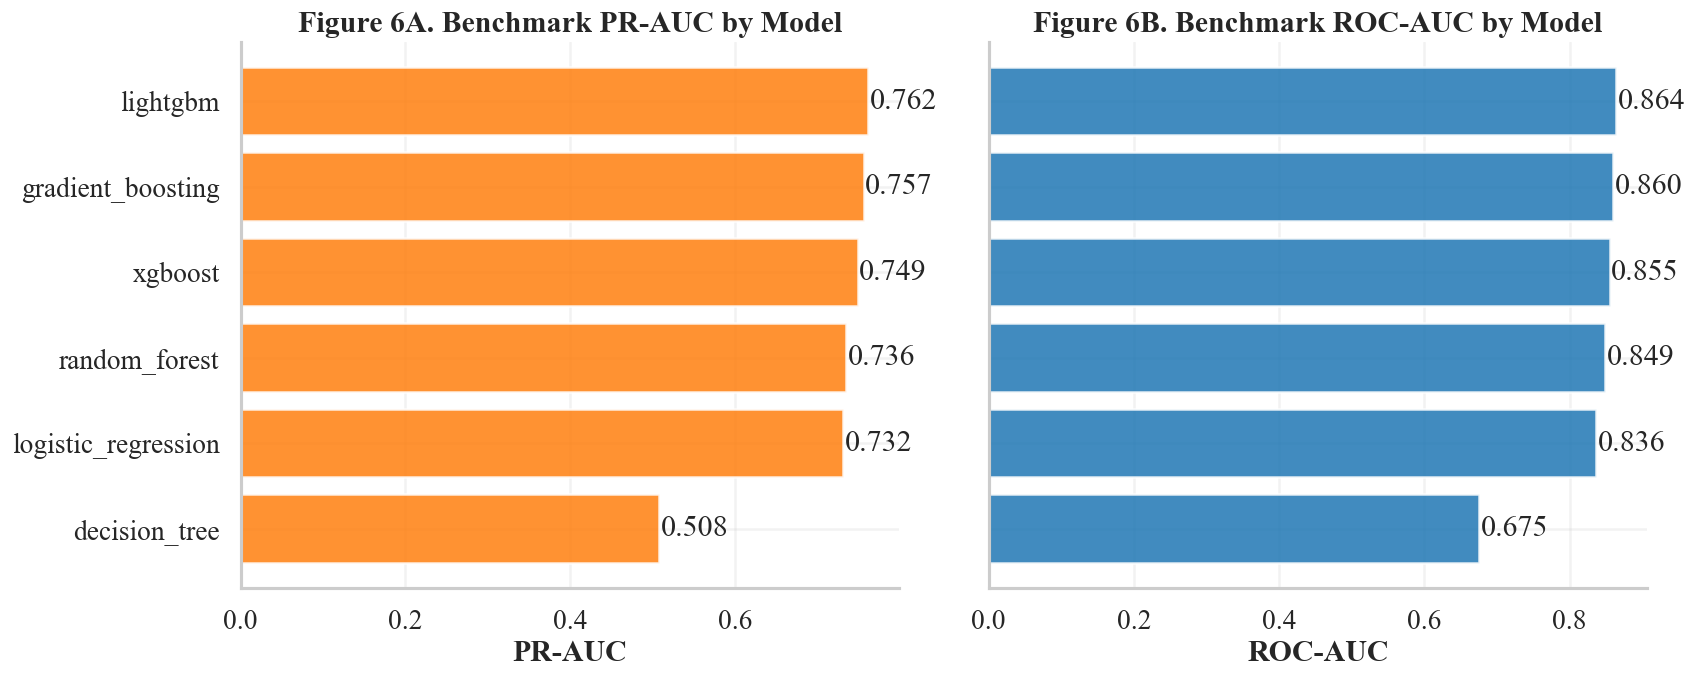

In [10]:
if ctx.get("benchmark_available"):
    plot_benchmark_model_comparison(ctx, FIG_DIR, fig_no=6)
else:
    print("Benchmark tables not available. Run: make benchmark")

In [11]:
if ctx.get("benchmark_available"):
    rankings = benchmark_rankings_table(ctx)
    display(rankings.style.set_caption("Model Rankings (Composite Score)"))

,rank,model,roc_auc,pr_auc,brier_score,ece
0,1,lightgbm,0.863758,0.761648,0.146529,0.029323
1,2,gradient_boosting,0.859764,0.756553,0.149040,0.032960
2,3,xgboost,0.855082,0.749193,0.151233,0.033099
3,4,random_forest,0.848707,0.735673,0.152934,0.026977
4,5,logistic_regression,0.836123,0.731924,0.159078,0.027693
5,6,decision_tree,0.675314,0.507834,0.216729,0.079090


In [12]:
if ctx.get("benchmark_available"):
    sig = benchmark_significance_table(ctx)
    display(
        sig.style
        .format({"p_value": "{:.4f}", "delta": "{:.4f}"}, na_rep="-")
        .set_caption("Paired Bootstrap Significance Tests vs Champion")
    )

,champion_model,challenger_model,metric,observed_delta,delta_ci_lower,delta_ci_upper,p_value_two_sided,significant_at_05,n_bootstraps
0,lightgbm,decision_tree,f1_max_f1_threshold,0.138683,0.127059,0.150271,0.000000,True,2000
1,lightgbm,gradient_boosting,f1_max_f1_threshold,0.001950,-0.002454,0.006240,0.405000,False,2000
2,lightgbm,logistic_regression,f1_max_f1_threshold,0.026517,0.019297,0.033522,0.000000,True,2000
3,lightgbm,random_forest,f1_max_f1_threshold,0.044323,0.035827,0.053355,0.000000,True,2000
4,lightgbm,xgboost,f1_max_f1_threshold,0.006317,0.001742,0.011035,0.007000,True,2000
5,lightgbm,decision_tree,pr_auc,0.253814,0.242776,0.264683,0.000000,True,2000
6,lightgbm,gradient_boosting,pr_auc,0.005095,0.001518,0.008844,0.009000,True,2000
7,lightgbm,logistic_regression,pr_auc,0.029724,0.023682,0.036837,0.000000,True,2000
8,lightgbm,random_forest,pr_auc,0.025974,0.020885,0.031297,0.000000,True,2000
9,lightgbm,xgboost,pr_auc,0.012454,0.009330,0.015785,0.000000,True,2000


## 2.9 Key Findings

1. **Champion model** achieves strong discriminative performance with ROC-AUC and PR-AUC well above quality gates.
2. **Calibration** after isotonic regression is good — predicted probabilities closely track observed rates.
3. **Temporal stability** is maintained across all test-set time buckets, indicating robustness to distribution shift.
4. **Bootstrap CIs** are narrow, confirming statistically reliable performance estimates.
5. **Benchmark comparison** shows the tree-based ensemble family significantly outperforms the logistic baseline.

For deeper diagnostics (feature importance, cost-sensitive analysis, counterfactuals), see **Notebook 03**.